In [1]:
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from random import shuffle
from resources.lattices import geometry, pStrainProperties, effProperties
from resources.calculations import calcUT, calcFT

In [2]:
### GLOBAL PATH INPUTS

pData = 'data/'

pAl          = pData + 'Al/'
pAK          = pAl + 'AK/'
pUTdisNodes  = pAK + 'Ductile-disNodes-FCC-12X16/'
pUTdisNodes2 = pAK + '20_RD02_10mm/'
pUTdisStruts = pAK + 'Ductile-disStruts-FCC-12X16/'
pFTdisNodes  = pAK + 'Fracture-disNodes/'

# Load Data

In [3]:
PATH  = pUTdisNodes2
dis   = 'disNodes'     # disNodes, disStruts

CSVin  = PATH + f'Ductile-{dis}-IN.csv'
CSVout = PATH + f'Ductile-{dis}-OUT.csv'

In [5]:
def load_AKdata(inputs, outputs):
    IN_df = pd.read_csv(inputs, index_col=0).sort_index()
    OUT_df = pd.read_csv(outputs, index_col=0).sort_index()

    perIN_df = IN_df.loc[:0].T
    perIN_df = perIN_df.rename(columns={0: "in"})
    perOUT_df = OUT_df.iloc[:2].T.iloc[1:]
    perOUT_df.columns = ["x", "y"]

    dIN_df = IN_df - IN_df.iloc[0].values
    dIN_df = dIN_df.loc[:, ~(dIN_df == 0.0).all()].sort_index()
    dOUT_df = OUT_df - OUT_df.iloc[1].values
    dOUT_df = dOUT_df.drop(columns='0')  # dOUT_df['0'] = OUT_df['0']
    dOUT_df = dOUT_df.iloc[1:].sort_index()
    OUT_df = OUT_df.iloc[1:].sort_index()
    
    return IN_df, OUT_df, perIN_df, perOUT_df, dIN_df, dOUT_df

IN_df, OUT_df, perIN_df, perOUT_df, dIN_df, dOUT_df = load_AKdata(CSVin, CSVout)

# Geometry

In [13]:
LAT = 'FCC'
l = 0.010
nnx = 12
nny = 18

# Prep Data

In [42]:
def prep_UTdata(dIN_df, dOUT_df, perOUT_df, OUT_df):
    dIN = dIN_df.to_numpy()
    dOUT = dOUT_df.to_numpy()
    xOUT = np.linspace(0, max(perOUT_df.x.tolist()), len(dOUT[0]))
    
    ducts, strens, stiffs = [], [], []
    for i, row in OUT_df.iterrows():
        UT_df = pd.DataFrame({'x':np.insert(xOUT,0,row[0]), 'y_sm':row})
        ductility, strength, stiffness = calcUT(UT_df)
        
        ducts.append(ductility)
        strens.append(strength)
        stiffs.append(stiffness)
        
    props = [ducts, strens, stiffs]
    return dIN, dOUT, xOUT, props

def find_outliers(data):
    mean = np.mean(data)
    stdev = np.std(data)
    
    outlier_idxs = [data.index(x) for x in data if (x < mean - 3*stdev) or (x > mean + 3*stdev) if data.index(x) != 0]
    return np.array(outlier_idxs, dtype="int")

def remove_outliers(dIN_r, dOUT_r, props_r, IN_df, OUT_df, dIN_df, dOUT_df):
    all_outlier_idxs = []
    for prop_r in props_r:
        idxs = find_outliers(data=prop_r)
        if len(idxs) == 0:
            continue
        for idx in idxs:
            all_outlier_idxs.append(idx)
    outlier_idxs = np.array(list(set(all_outlier_idxs)))
    
    if len(outlier_idxs) > 0:
        dIN = np.delete(dIN_r, outlier_idxs, axis=0)
        dOUT = np.delete(dOUT_r, outlier_idxs, axis=0)
        IN_df = IN_df.drop(IN_df.iloc[outlier_idxs].index)
        OUT_df = OUT_df.drop(OUT_df.iloc[outlier_idxs].index)
        dIN_df = dIN_df.drop(dIN_df.iloc[outlier_idxs].index)
        dOUT_df = dOUT_df.drop(dOUT_df.iloc[outlier_idxs].index)
        props = []
        for prop_r in props_r:
            prop = np.delete(prop_r, outlier_idxs, axis=0)
            props.append(prop)
        props = np.array(props).tolist()
    else:
        dIN, dOUT, props = dIN_r, dOUT_r, props_r
    
    return dIN, dOUT, props, IN_df, OUT_df, dIN_df, dOUT_df

def split_data(dIN, dOUT, PATH, split=0.85):
    idxs = list(range(len(dOUT)))
    shuffle(idxs)
    train_idxs = idxs[:int(split*len(dOUT))]
    test_idxs = [i for i in idxs if i not in train_idxs]
    
    train_in = dIN[train_idxs]
    test_in = dIN[test_idxs]
    train_out = dOUT[train_idxs]
    test_out = dOUT[test_idxs]
    
    pd.DataFrame(train_in).to_csv(PATH + "NN-UT-dN-trainIN.csv")
    pd.DataFrame(test_in).to_csv(PATH + "NN-UT-dN-testIN.csv")
    pd.DataFrame(train_out).to_csv(PATH + "NN-UT-dN-trainOUT.csv")
    pd.DataFrame(test_out).to_csv(PATH + "NN-UT-dN-testOUT.csv")
    
    return train_in, train_out, test_in, test_out

In [43]:
dIN_r, dOUT_r, xOUT, props_r = prep_UTdata(dIN_df, dOUT_df, perOUT_df, OUT_df)
dIN, dOUT, props, IN_df, OUT_df, dIN_df, dOUT_df = remove_outliers(dIN_r, dOUT_r, props_r, IN_df, OUT_df, dIN_df, dOUT_df)
train_in, train_out, test_in, test_out = split_data(dIN[1:], dOUT[1:], PATH, split=0.85)

In [44]:
def locSims(prop, OUT_df):
    max_idx, min_idx = prop.index(max(prop[1:])), prop.index(min(prop[1:]))
    nSim_max, nSim_min = OUT_df.iloc[max_idx].name, OUT_df.iloc[min_idx].name
    return nSim_max, nSim_min

nSim_max, nSim_min = locSims(props[0], OUT_df)
print(f"UT -- max: {nSim_max}, min: {nSim_min}")

UT -- max: 4693, min: 4106


In [45]:
def plot_frequency(raw_data, data, test):
    raw_data = np.array(data)
    data = np.array(data)
    
    if test == "UT":
        x_label = 'Normalized Ductility'
    elif test == "FT":
        x_label = 'Normalized Fracture Toughness ($K_{IC}$)'
    
    fig1, (ax1, ax2) = plt.subplots(1, 2)
    fig1.set_figheight(5)
    fig1.set_figwidth(15)
    
    ax1.set_title('Raw Data')
    ax1.axvline(x=raw_data[0]/raw_data[0], color='orangered', label="Perfect")
    ax1.hist(raw_data[1:]/raw_data[0], bins=int(len(data)/50), label='Disordered')
    ax1.set_ylabel('Frequency')
    ax1.set_xlabel(x_label)
    ax1.legend()
    
    ax2.set_title('Without Outliers')
    ax2.axvline(x=data[0]/data[0], color='orangered', label="Perfect")
    ax2.hist(data[1:]/data[0], bins=int(len(data)/50), label='Disordered')
    ax2.set_ylabel('Frequency')
    ax2.set_xlabel(x_label)
    ax2.legend()
    
    plt.show()

def plot_properties(x_data, y_data, test):
    x_data = np.array(x_data)
    y_data = np.array(y_data)
    
    if test == "UT":
        title = "Uniaxial Tension"
        x_label = 'Normalized Ductility'
        y_label = 'Normalized Strength'
    elif test == "FT":
        title = "Compact Tension"
        x_label = 'Normalized Fracture Toughness ($K_{IC}$)'
        y_label = 'Normalized Displacement'
    
    fig1, ax1 = plt.subplots(1, 1)
    fig1.set_figheight(5)
    fig1.set_figwidth(10)
    
    ax1.set_title(title)
    ax1.scatter(x_data[0]/x_data[0], y_data[0]/y_data[0], label='Perfect')
    ax1.scatter(x_data[1:]/x_data[0], y_data[1:]/y_data[0], label='Disordered')
    ax1.axvline(x=1, linestyle='--')
    ax1.axhline(y=1, linestyle='--')
    ax1.set_ylabel(y_label)
    ax1.set_xlabel(x_label)
    ax1.legend()
    
    plt.show()

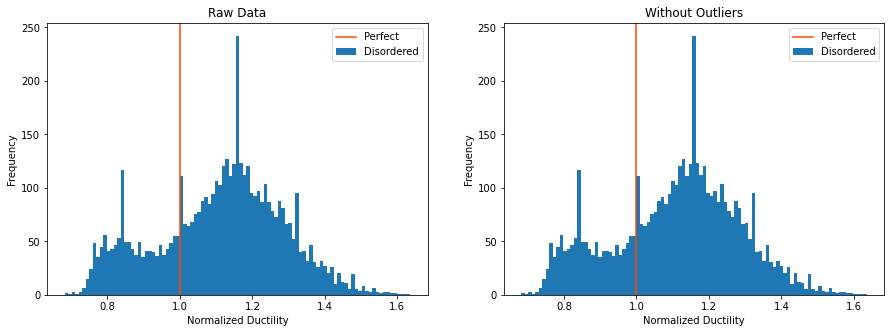

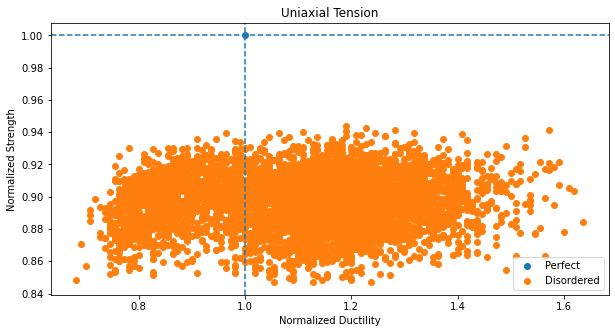

In [46]:
plot_freq = True
plot_props = True

dduct, sstr, sstiff = 0, 1, 2
kk, FF, dd = 0, 2, 3

U1, U2 = dduct, sstr
F1, F2 = kk, dd

if plot_freq:
    plot_frequency(props_r[U1], props[U1], "UT")
if plot_props:
    plot_properties(props[U1], props[U2], "UT")

[4406, 2855, 3646, 3087, 4400, 2201, 1938, 2183, 512, 4008, 2783, 2904, 540, 2725, 3520]


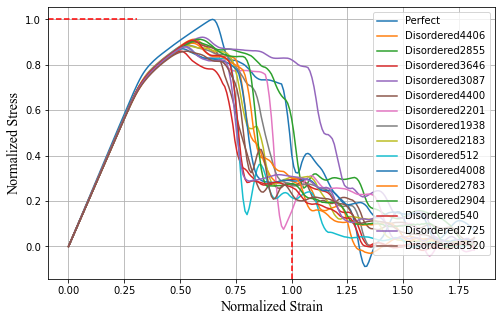

In [47]:
def plot_curve(UT_OUT_df, UT_xOUT, idx=None, q=15):
    fig2, ax1 = plt.subplots(1, 1)
    fig2.set_figheight(5)
    fig2.set_figwidth(8)
    
    UTp = UT_OUT_df.loc[0].tolist()[1:]
    UTindx = int(UT_OUT_df.loc[0].tolist()[0])
    ax1.plot(UT_xOUT/UT_xOUT[UTindx], [i/max(UTp) for i in UTp], label="Perfect")
    ax1.axvline(x=1, ymax=0.2, c='r', linestyle='--')
    ax1.axhline(y=1, xmax=0.2, c='r', linestyle='--')
    
    if idx:
        UTd = UT_OUT_df.loc[idx].tolist()[1:]
        UTindx2 = int(UT_OUT_df.loc[idx].tolist()[0])
        ax1.plot(UT_xOUT/UT_xOUT[UTindx], [i/max(UTp) for i in UTd], label=f'Disordered{idx}')
        ax1.axvline(x=UT_xOUT[UTindx2]/UT_xOUT[UTindx], ymax=0.2, c='g', linestyle='--')
        ax1.axhline(y=max(UTd)/max(UTp), xmax=0.2, c='g', linestyle='--')
        
    else:
        UT_idxs = UT_OUT_df.index.tolist()[1:]
        if q == 'all':
            UT_idxs = UT_idxs
        UT_idxs = random.sample(UT_idxs, q)
        print(UT_idxs)
                
        for idx in UT_idxs:
            UTd = UT_OUT_df.loc[idx].tolist()[1:]
            ax1.plot(UT_xOUT/UT_xOUT[UTindx], [i/max(UTp) for i in UTd], label=f'Disordered{idx}')
    
    ax1.set_ylabel('Normalized Stress', fontsize=14, fontname="Times New Roman")
    ax1.set_xlabel('Normalized Strain', fontsize=14, fontname="Times New Roman")
    if q != "all":
        ax1.legend()
    ax1.grid()
    
    plt.show()

plot_curve(OUT_df, xOUT, idx=None, q=15)